In [146]:
print("""In this Colab, should complete the following tasks:

Examine a dataset containing measurements derived from images of two species of Turkish rice.
Create a binary classifier to sort grains of rice into the two species.
Evaluate the performance of the model.
Learning objectives
By completing this Colab, should learn:

How to train a binary classifier.
How to calculate metrics for a binary classifier at different thresholds.
How to compare AUC and ROC of two different models.""")

In this Colab, should complete the following tasks:

Examine a dataset containing measurements derived from images of two species of Turkish rice.
Create a binary classifier to sort grains of rice into the two species.
Evaluate the performance of the model.
Learning objectives
By completing this Colab, should learn:

How to train a binary classifier.
How to calculate metrics for a binary classifier at different thresholds.
How to compare AUC and ROC of two different models.


In [147]:
# @title Load the imports

In [148]:
import keras
import ml_edu.experiment
import ml_edu.results
import numpy as np
import pandas as pd
import plotly.express as px
import plotly
import ipywidgets as widgets
# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

print("Ran the import statements.")

Ran the import statements.


In [149]:
print("Load the dataset")

Load the dataset


In [150]:
rice_dataset_raw = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/Rice_Cammeo_Osmancik.csv")

In [151]:
print("Read and provide statistics on the dataset.")

Read and provide statistics on the dataset.


In [152]:
rice_dataset = rice_dataset_raw[[
    'Area',
    'Perimeter',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Eccentricity',
    'Convex_Area',
    'Extent',
    'Class',
]]



print("""From the summary statistics Down, answer the following questions:

What are the min and max lengths (major axis length, given in pixels) of the rice grains?
What is the range of areas between the smallest and largest rice grains?
How many standard deviations (std) is the largest rice grain's perimeter from the mean?
""")


rice_dataset.describe()


From the summary statistics Down, answer the following questions:

What are the min and max lengths (major axis length, given in pixels) of the rice grains?
What is the range of areas between the smallest and largest rice grains?
How many standard deviations (std) is the largest rice grain's perimeter from the mean?



,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0,3810.0
mean,12667.7,454.2,188.8,86.3,0.9,12952.5,0.7
std,1732.4,35.6,17.4,5.7,0.0,1777.0,0.1
min,7551.0,359.1,145.3,59.5,0.8,7723.0,0.5
25%,11370.5,426.1,174.4,82.7,0.9,11626.2,0.6
50%,12421.5,448.9,185.8,86.4,0.9,12706.5,0.6
75%,13950.0,483.7,203.6,90.1,0.9,14284.0,0.7
max,18913.0,548.4,239.0,107.5,0.9,19099.0,0.9


In [153]:
# @title Solutions (run the cell to get the answers)

In [154]:
print(
    f'The shortest grain is {rice_dataset.Major_Axis_Length.min():.1f}px long,'
    f' while the longest is {rice_dataset.Major_Axis_Length.max():.1f}px.'
)

print(
    f'The smallest rice grain has an area of {rice_dataset.Area.min()}px, while'
    f' the largest has an area of {rice_dataset.Area.max()}px.')

print(
    'The largest rice grain, with a perimeter of'
    f' {rice_dataset.Perimeter.max():.1f}px, is'
    f' ~{(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean())/rice_dataset.Perimeter.std():.1f} standard'
    f' deviations ({rice_dataset.Perimeter.std():.1f}) from the mean'
    f' ({rice_dataset.Perimeter.mean():.1f}px).')

print(
    f'This is calculated as: ({rice_dataset.Perimeter.max():.1f} -'
    f' {rice_dataset.Perimeter.mean():.1f})/{rice_dataset.Perimeter.std():.1f} ='
    f' {(rice_dataset.Perimeter.max() - rice_dataset.Perimeter.mean())/rice_dataset.Perimeter.std():.1f}')

The shortest grain is 145.3px long, while the longest is 239.0px.
The smallest rice grain has an area of 7551px, while the largest has an area of 18913px.
The largest rice grain, with a perimeter of 548.4px, is ~2.6 standard deviations (35.6) from the mean (454.2px).
This is calculated as: (548.4 - 454.2)/35.6 = 2.6


In [155]:
print("Create five 2D plots of the features against each other, color-coded by class.")

Create five 2D plots of the features against each other, color-coded by class.


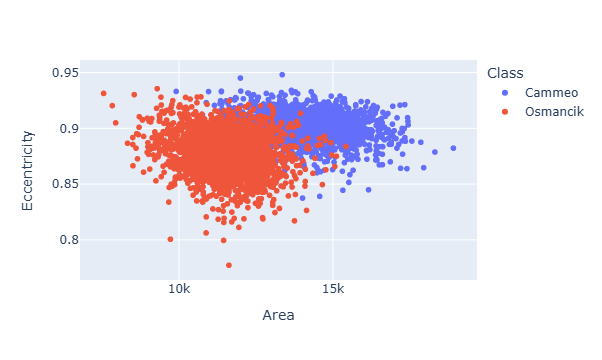

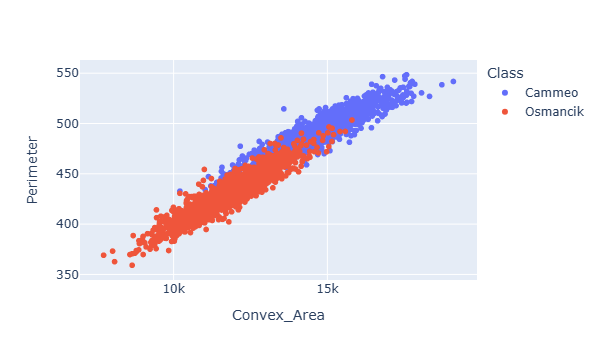

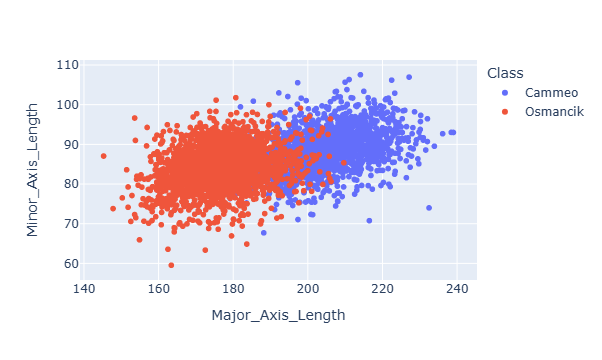

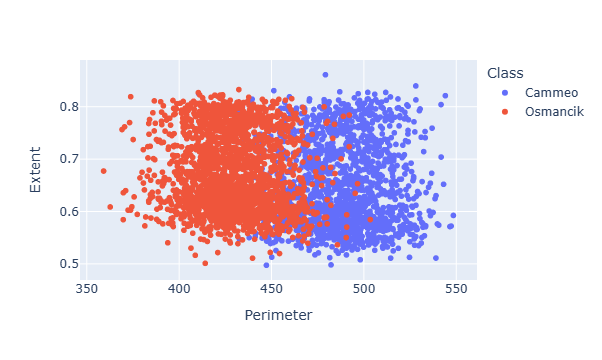

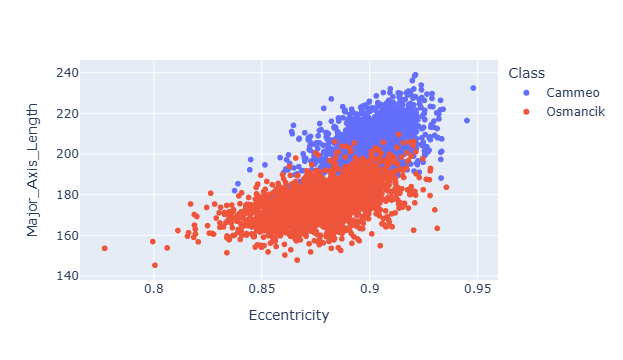

In [156]:
for x_axis_data, y_axis_data in [
    ('Area', 'Eccentricity'),
    ('Convex_Area', 'Perimeter'),
    ('Major_Axis_Length', 'Minor_Axis_Length'),
    ('Perimeter', 'Extent'),
    ('Eccentricity', 'Major_Axis_Length'),
]:
  px.scatter(rice_dataset, x = x_axis_data, y = y_axis_data, color='Class').show()

In [157]:
# feel free to change the x,y and z futures names.

px.scatter_3d(
    rice_dataset,
    x='Eccentricity',
    y='Area',
    z='Major_Axis_Length',
    color='Class',
).show()

In [158]:
# Calculate the Z-scores of each numerical column in the raw data and write
# them into a new DataFrame named df_norm.

feature_mean = rice_dataset.mean(numeric_only=True)
feature_std = rice_dataset.std(numeric_only=True)
numerical_features = rice_dataset.select_dtypes('number').columns

normalized_dataset = (
    rice_dataset[numerical_features] - feature_mean / feature_std
)

# Copy the class to the new dataframe
normalized_dataset['Class'] = rice_dataset['Class']

# Examine some of the values of the normalized training set. Notice that most
# Z-scores fall between -2 and +2.
normalized_dataset.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15223.7,512.8,218.9,70.0,-41.7,15609.7,-8.0,Cammeo
1,14648.7,481.6,195.2,76.7,-41.7,15064.7,-8.0,Cammeo
2,14626.7,488.4,203.3,72.7,-41.7,14946.7,-7.9,Cammeo
3,13168.7,445.6,182.5,72.4,-41.7,13360.7,-7.9,Cammeo
4,14680.7,494.4,200.9,74.2,-41.7,15254.7,-7.9,Cammeo


In [159]:
print('''Set the random seeds
To make experiments reproducible, we set the seed of the random number generators. This means that the order in which the data is shuffled, the values of the random weight initializations, etc, will all be the same each time the colab is run.''')

Set the random seeds
To make experiments reproducible, we set the seed of the random number generators. This means that the order in which the data is shuffled, the values of the random weight initializations, etc, will all be the same each time the colab is run.


In [160]:
keras.utils.set_random_seed(42)

In [161]:
print('''To train the model, we'll arbritrarily assign the Cammeo species a label of '1' and the Osmancik species a label of '0'.''')

# Create a column setting the Cammeo label to '1' and the Osmancik label to '0'
# then show 10 randomly selected rows.
normalized_dataset['Class_Bool'] = (
    # Returns true if class is Cammeo, and false if class is Osmancik
    normalized_dataset['Class'] == 'Cammeo'
).astype(int)
normalized_dataset.sample(10)

To train the model, we'll arbritrarily assign the Cammeo species a label of '1' and the Osmancik species a label of '0'.


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
1011,12434.7,446.8,176.7,72.1,-41.7,12933.7,-8.0,Cammeo,1
3185,12400.7,424.3,168.9,73.8,-41.7,12590.7,-7.9,Osmancik,0
3698,12859.7,436.3,170.9,76.3,-41.7,13144.7,-7.9,Osmancik,0
897,13082.7,460.2,191.8,68.2,-41.7,13323.7,-7.8,Cammeo,1
3245,10351.7,396.8,162.5,61.8,-41.7,10502.7,-8.0,Osmancik,0
478,12978.7,449.4,184.7,71.0,-41.7,13280.7,-7.8,Cammeo,1
1731,11920.7,414.3,164.2,72.8,-41.7,12113.7,-7.9,Osmancik,0
1025,13613.7,466.0,189.2,73.0,-41.7,14060.7,-7.9,Cammeo,1
429,14787.7,484.8,202.8,74.8,-41.7,14994.7,-7.8,Cammeo,1
1330,11933.7,439.8,185.2,63.6,-41.7,12123.7,-7.9,Cammeo,1


In [162]:
print('''We can then randomize and partition the dataset into train, validation, and test splits, consisting of 80%, 10%, and 10% of the dataset respectively.

We will use the training data to learn the model parameters, then use the validation data to evaluate different models, and finally use the test data to compute the final metrics for the model that performed best on the validation data.''')

# Create indices at the 80th and 90th percentiles
number_samples = len(normalized_dataset)
index_80th = round(number_samples * 0.8)
index_90th = index_80th + round(number_samples * 0.1)

# Randomize order and split into train, validation, and test with a .8, .1, .1 split
shuffled_dataset = normalized_dataset.sample(frac=1, random_state=100)

train_data = shuffled_dataset.iloc[0:index_80th]
validation_data = shuffled_dataset.iloc[index_80th:index_90th]
test_data = shuffled_dataset.iloc[index_90th:]

# Show the first five rows of the last split
test_data.head()

We can then randomize and partition the dataset into train, validation, and test splits, consisting of 80%, 10%, and 10% of the dataset respectively.

We will use the training data to learn the model parameters, then use the validation data to evaluate different models, and finally use the test data to compute the final metrics for the model that performed best on the validation data.


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class,Class_Bool
2405,11900.7,417.9,163.6,73.0,-41.7,12154.7,-7.9,Osmancik,0
3062,12317.7,441.3,181.9,67.5,-41.7,12575.7,-7.8,Osmancik,0
1155,15053.7,484.6,196.8,78.0,-41.7,15319.7,-7.9,Cammeo,1
660,14678.7,477.6,192.2,78.8,-41.7,15057.7,-8.0,Cammeo,1
2451,10659.7,399.0,153.1,69.7,-41.7,10979.7,-7.9,Osmancik,0


In [163]:
print('''to prevent the model from getting the label as input during training, which is called label leakage. This can be done by storing features and labels as separate variables.''')

to prevent the model from getting the label as input during training, which is called label leakage. This can be done by storing features and labels as separate variables.


In [164]:
label_columns = ['Class', 'Class_Bool']

train_features = train_data.drop(columns=label_columns)
train_labels = train_data['Class_Bool'].to_numpy()

validation_features = validation_data.drop(columns=label_columns)
validation_labels = validation_data['Class_Bool'].to_numpy()

test_features = test_data.drop(columns=label_columns)
test_labels = test_data['Class_Bool'].to_numpy()

In [165]:
print("Train the model")

Train the model


In [166]:
# Name of the features we'll train our model on.
input_features = [
    'Eccentricity',
    'Major_Axis_Length',
    'Area',
]

In [167]:
print("Define functions that build and train a model")
# The following code cell defines two functions:

# create_model(inputs, learning_rate, metrics), which defines the model's architecture.
# train_model(model, dataset, epochs, label_name, batch_size, shuffle), uses input features and labels to train the model.
# Note: create_model applies the sigmoid function to perform logistic regression.

# We also define two helpful data structures: ExperimentSettings and Experiment. We use these simple classes to keep track of our experiments, allowing us to know what hyperparameters were used and what the results were. In ExperimentSettings, we store all values describing an experiment (i.e., hyperparameters). Then, we store the results of a training run (i.e., the model and the training metrics) into an Experiment instance, along with the ExperimentSettings used for that experiment.

Define functions that build and train a model


In [168]:
# @title Define the functions that create and train a model.


def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple classification model."""
  model_inputs = [
      keras.Input(name=feature, shape=(1,))
      for feature in settings.input_features
  ]
  # Use a Concatenate layer to assemble the different inputs into a single
  # tensor which will be given as input to the Dense layer.
  # For example: [input_1[0][0], input_2[0][0]]

  concatenated_inputs = keras.layers.Concatenate()(model_inputs)
  model_output = keras.layers.Dense(
      units=1, name='dense_layer', activation=keras.activations.sigmoid
  )(concatenated_inputs)
  model = keras.Model(inputs=model_inputs, outputs=model_output)
  # Call the compile method to transform the layers into a model that
  # Keras can execute.  Notice that we're using a different loss
  # function for classification than for regression.
  model.compile(
      optimizer=keras.optimizers.RMSprop(
          settings.learning_rate
      ),
      loss=keras.losses.BinaryCrossentropy(),
      metrics=metrics,
  )
  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    labels: np.ndarray,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Feed a dataset into the model in order to train it."""

  # The x parameter of keras.Model.fit can be a list of arrays, where
  # each array contains the data for one feature.
  features = {
      feature_name: np.array(dataset[feature_name])
      for feature_name in settings.input_features
  }

  history = model.fit(
      x=features,
      y=labels,
      batch_size=settings.batch_size,
      epochs=settings.number_epochs,
  )

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )


print('Defined the create_model and train_model functions.')

Defined the create_model and train_model functions.


In [169]:
print('''Invoke the creating, training, and plotting functions
The following code specifies the hyperparameters, invokes the functions to create and train the model, then plots the results, including accuracy, precision, and recall.
''')

Invoke the creating, training, and plotting functions
The following code specifies the hyperparameters, invokes the functions to create and train the model, then plots the results, including accuracy, precision, and recall.



Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1958.0176 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1755.9517 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1565.0325 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1374.4242 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1183.8275 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 993.2312 - precision: 0.0000e+00 - recall: 0.0000e+00 
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 802.6348 - precision: 0.0000e+00 

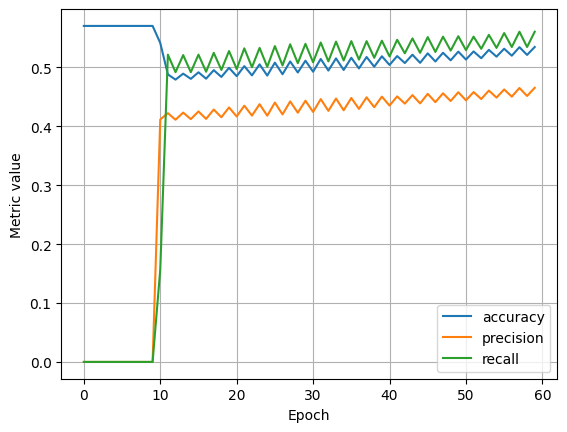

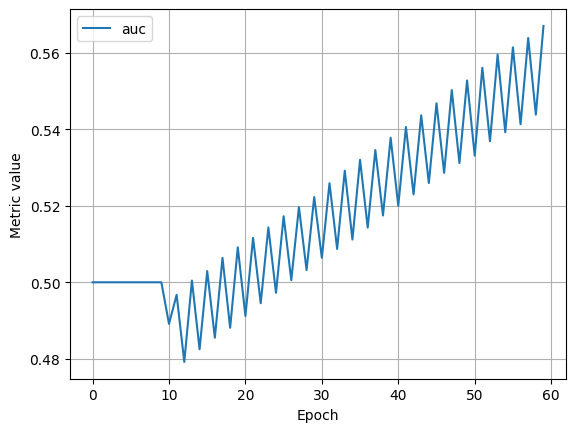

In [170]:
# Let's define our first experiment settings.
settings = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.35,
    input_features=input_features,
)

metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy', threshold=settings.classification_threshold
    ),
    keras.metrics.Precision(
        name='precision', thresholds=settings.classification_threshold
    ),
    keras.metrics.Recall(
        name='recall', thresholds=settings.classification_threshold
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),
]

# Establish the model's topography.
model = create_model(settings, metrics)

# Train the model on the training set.
experiment = train_model(
    'baseline', model, train_features, train_labels, settings
)

# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(experiment, ['accuracy', 'precision', 'recall'])
ml_edu.results.plot_experiment_metrics(experiment, ['auc'])

In [171]:
print('Classification threshold up there is set at .35. Try playing with the threshold, then the learning rate, to see what changes.')

Classification threshold up there is set at .35. Try playing with the threshold, then the learning rate, to see what changes.


In [172]:
print('''Evaluate the model against the validation set
At the end of model training, you ended up with a certain accuracy against the training set. Invoke the following code cell to determine your model's accuracy against the validation set.''')


Evaluate the model against the validation set
At the end of model training, you ended up with a certain accuracy against the training set. Invoke the following code cell to determine your model's accuracy against the validation set.


In [173]:

def compare_train_validation(experiment: ml_edu.experiment.Experiment, validation_metrics: dict[str, float]):
  print('Comparing metrics between train and validation:')
  for metric, validation_value in validation_metrics.items():
    print('------')
    print(f'Train {metric}: {experiment.get_final_metric_value(metric):.4f}')
    print(f'Validation {metric}:  {validation_value:.4f}')


# Evaluate validation metrics
validation_metrics = experiment.evaluate(validation_features, validation_labels)
compare_train_validation(experiment, validation_metrics)

Comparing metrics between train and validation:
------
Train accuracy: 0.5348
Validation accuracy:  0.5512
------
Train auc: 0.5670
Validation auc:  0.5393
------
Train loss: 2.9218
Validation loss:  2.6806
------
Train precision: 0.4654
Validation precision:  0.4853
------
Train recall: 0.5607
Validation recall:  0.1953


In [184]:
# Features used to train the model on.
# Specify all features.
all_input_features = [
    'Eccentricity',
    'Major_Axis_Length',
    'Minor_Axis_Length',
    'Area',
    'Convex_Area',
    'Perimeter',
    'Extent',
]

In [185]:
print('Train the full-featured model and calculate')

Train the full-featured model and calculate


Epoch 1/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 4069.8357 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 3656.5686 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 3/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 3266.0986 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 4/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 2876.2654 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 5/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 2486.4561 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 6/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 2096.6479 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 7/60
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5705 - auc: 0.5000 - loss: 1706.8401 - precision: 0.0000e+00

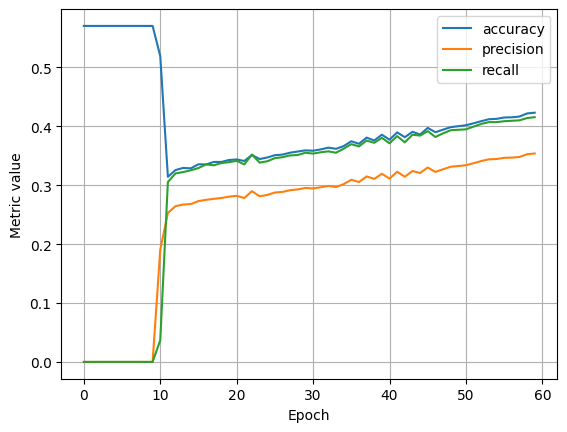

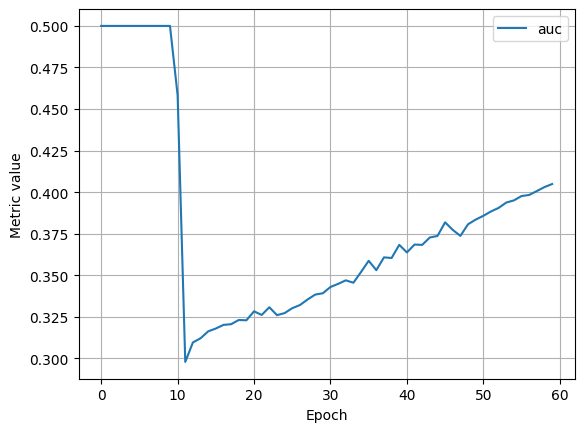

In [186]:
settings_all_features = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=60,
    batch_size=100,
    classification_threshold=0.5,
    input_features=all_input_features,
)

# Modify the following definition of METRICS to generate
# not only accuracy and precision, but also recall:
metrics = [
    keras.metrics.BinaryAccuracy(
        name='accuracy',
        threshold=settings_all_features.classification_threshold,
    ),
    keras.metrics.Precision(
        name='precision',
        thresholds=settings_all_features.classification_threshold,
    ),
    keras.metrics.Recall(
        name='recall', thresholds=settings_all_features.classification_threshold
    ),
    keras.metrics.AUC(num_thresholds=100, name='auc'),
]

# Establish the model's topography.
model_all_features = create_model(settings_all_features, metrics)

# Train the model on the training set.
experiment_all_features = train_model(
    'all features',
    model_all_features,
    train_features,
    train_labels,
    settings_all_features,
)

# Plot metrics vs. epochs
ml_edu.results.plot_experiment_metrics(
    experiment_all_features, ['accuracy', 'precision', 'recall']
)
ml_edu.results.plot_experiment_metrics(experiment_all_features, ['auc'])

In [187]:
# Evaluate full-featured model on validation split

validation_metrics_all_features = experiment_all_features.evaluate(
    validation_features,
    validation_labels,
)
compare_train_validation(experiment_all_features, validation_metrics_all_features)

Comparing metrics between train and validation:
------
Train accuracy: 0.4232
Validation accuracy:  0.3806
------
Train auc: 0.4049
Validation auc:  0.3586
------
Train loss: 12.8975
Validation loss:  12.5499
------
Train precision: 0.3539
Validation precision:  0.3412
------
Train recall: 0.4156
Validation recall:  0.4260


In [178]:
print('This second model has closer train and validation metrics, suggesting it overfit less to the training data.')

This second model has closer train and validation metrics, suggesting it overfit less to the training data.


In [179]:
print('''Comparing our two models
With our simple experimentation framework, we can keep track of which experiments we ran, and what the results were. We also defined a helper function which allows us to easily compare two or more models, both during training and when evaluated on the validation set.''')

Comparing our two models
With our simple experimentation framework, we can keep track of which experiments we ran, and what the results were. We also defined a helper function which allows us to easily compare two or more models, both during training and when evaluated on the validation set.


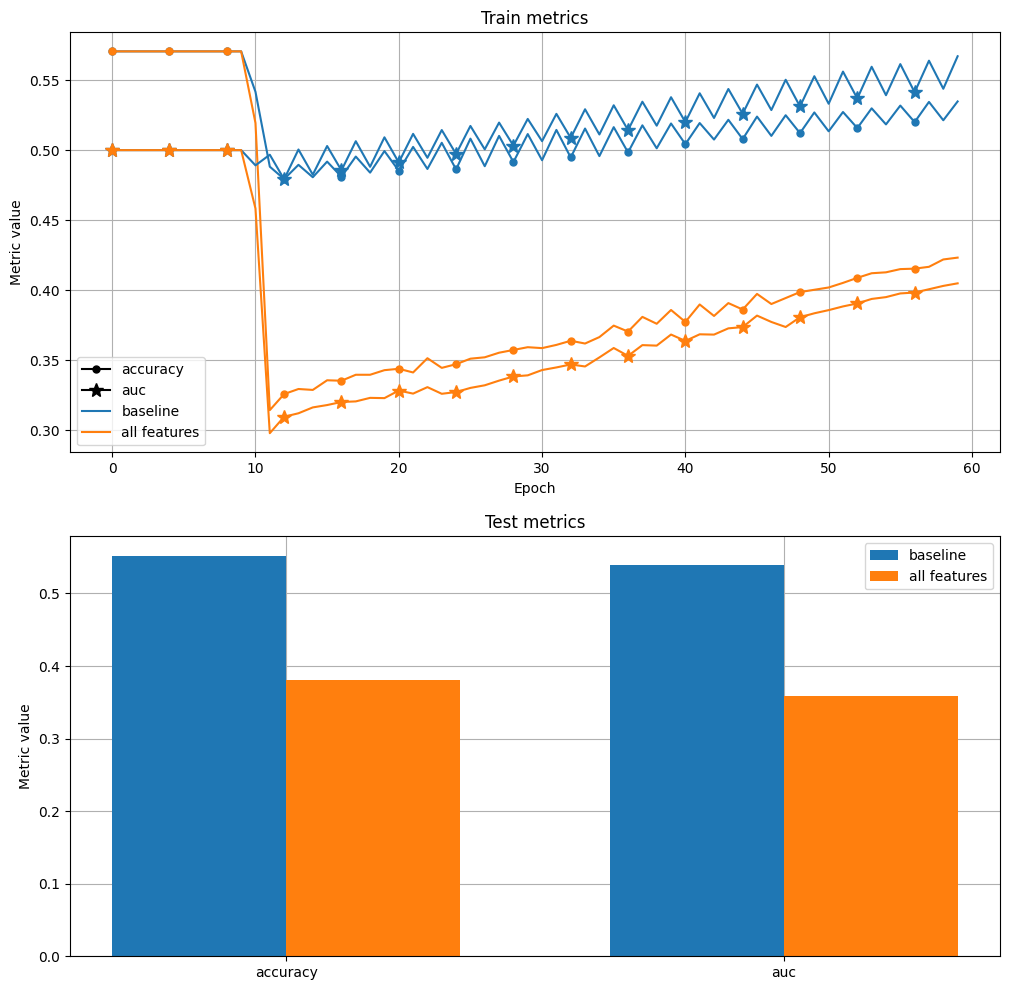

In [188]:
ml_edu.results.compare_experiment([experiment, experiment_all_features],
                                  ['accuracy', 'auc'],
                                  validation_features, validation_labels)

In [181]:
print('''Computing the final test metrics

To estimate the peformance of our model on unseen data, we can now compute the metrics of the best model on the test data. This final step must be done once experimentation is over and we have selected the model we want to use. Any model comparison must be done using the validation set, to avoid accidentally selecting a model which is tailored for our test set.

This final step is also the opportunity to check for potential overfitting: if the validation and test metrics are very different, it might be a sign that the selection process done using the validation set led to a model that doesn't generalize well, possibly because the validation set is not representative of the overall data distribution. In that case, the best solution is to shuffle the data and re-assign the train, validation, and test sets, before running your experiments again.''')

Computing the final test metrics

To estimate the peformance of our model on unseen data, we can now compute the metrics of the best model on the test data. This final step must be done once experimentation is over and we have selected the model we want to use. Any model comparison must be done using the validation set, to avoid accidentally selecting a model which is tailored for our test set.

This final step is also the opportunity to check for potential overfitting: if the validation and test metrics are very different, it might be a sign that the selection process done using the validation set led to a model that doesn't generalize well, possibly because the validation set is not representative of the overall data distribution. In that case, the best solution is to shuffle the data and re-assign the train, validation, and test sets, before running your experiments again.


In [189]:
test_metrics_all_features = experiment_all_features.evaluate(
    test_features,
    test_labels,
)
for metric, test_value in test_metrics_all_features.items():
  print(f'Test {metric}:  {test_value:.4f}')

Test accuracy:  0.3570
Test auc:  0.3224
Test loss:  12.5122
Test precision:  0.2687
Test recall:  0.3553
